## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 12 · Planning visuals: where the measures land, who they reach, in what order

Four figures a local area energy plan needs, all on every building footprint of the study area (non-residential
in grey, so the map is the town, not a scatter), built from the scenarios of notebook 10:

1. **the retrofit gap** — the space heat the fabric package closes per building, and the eligibility physics
   behind it (cavity, solid-masonry and other walls);
2. **energy and heating mix by ward** — pies in the map: delivered gas / electricity / other per ward in the
   baseline, and the heating technologies per ward after electrification;
3. **prioritisation strategies** — at which budget percentile each building is treated under three delivery
   orders: carbon-first (carbon saved per pound), equity-first (deprived, fuel-poor, rented and hard-to-treat
   homes first) and coordinated (substation cells with the largest electrified peak first, then carbon per pound
   inside each cell);
4. **carbon opportunity × neighbourhood vulnerability** — a bivariate map of the deep-package carbon saving
   tercile against the LSOA deprivation tercile (Stevens' 3 × 3 scheme).

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import config as CFG
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
from ukubem.calibrate import (ArchetypeCalibrator, PHYS_BOUNDS, POST_FIXED, make_representatives, _stock_delivered, evaluate_on)
from ukubem import metrics as M, maps, profiles, measures, stock
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
theta = json.load(open(UBEM_OUT / "06_calibrated_theta.json")); phys, post = theta["physics"], theta["post"]
inputs0 = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
inputs, reps = make_representatives(inputs0)
folds = pd.read_csv(CV_FOLDS)
A_cal = UKGeometryAssumptions().with_(wall_u_scale=phys["wall_u_scale"], roof_u_scale=phys["roof_u_scale"], window_u_scale=phys["window_u_scale"],
                                      infil_scale=phys["infil_scale"], gains_scale=phys["gains_scale"], setpoint_offset_c=phys["setpoint_offset_c"],
                                      stochastic_setback_c=phys.get("setback_c", 12.0))
inten_cal = pd.read_csv(UBEM_OUT / "06_archetype_intensities_calibrated.csv", index_col=0)
stock_cal = pd.read_parquet(UBEM_OUT / "06_stock_calibrated.parquet")
print(f"{len(inputs):,} dwellings, {len(reps)} representatives, {folds['fold'].nunique()} spatial folds; calibrated physics {phys}")

57,300 dwellings, 102 representatives, 7 spatial folds; calibrated physics {'wall_u_scale': 1.0652602409167062, 'roof_u_scale': 1.1248578219743166, 'window_u_scale': 1.25, 'infil_scale': 0.8129959823081263, 'gains_scale': 0.8155295436843902, 'setpoint_offset_c': 1.0, 'setback_c': 15.691329877128062}


In [3]:
from matplotlib.patches import Wedge, Circle
from ukubem import pubstyle
pubstyle.apply()
L = maps.load_layers(CFG, town_only=True)
urban_ids = inputs.index[inputs["in_study_area"].astype(bool)]; urban = inputs.loc[urban_ids]
scen = {k: pd.read_parquet(UBEM_OUT / f"10_scenario_{k}.parquet") for k in measures.PACKAGES}
u0, u1, u2, u5 = (scen[k].loc[urban_ids] for k in ("U0_baseline", "U1_electrification", "U2_envelope", "U5_envelope_elec_pv"))
econ = pd.read_csv(UBEM_OUT / "10_low_hanging_fruit_U5.csv", index_col=0).reindex(urban_ids)
social = pd.read_csv(LSOA_SOCIAL_CSV).set_index("LSOA")[["imd_decile", "fuel_poor_pct"]] if Path(LSOA_SOCIAL_CSV).exists() else None
net = pd.read_csv(NETWORK_BUILDINGS_CSV, usecols=["egid", "id_transformer"]); net["UPRN"] = net["egid"].astype("Int64").astype(str)
cell_of = urban[["UPRN"]].assign(UPRN=lambda d: d["UPRN"].astype("Int64").astype(str)).merge(net[["UPRN", "id_transformer"]], on="UPRN", how="left")["id_transformer"].to_numpy()
cells = pd.read_csv(UBEM_OUT / "10_substation_cells.csv", index_col=0) if (UBEM_OUT / "10_substation_cells.csv").exists() else None
FIG_PLAN = FIG / "planning"; FIG_PLAN.mkdir(exist_ok=True)
print(f"{len(urban):,} dwellings, {urban['toid'].nunique():,} buildings; substation cell known for {pd.notna(cell_of).mean():.0%}")

28,663 dwellings, 21,631 buildings; substation cell known for 100%


## 1 · The retrofit gap (U0 → U2), spatially and by construction

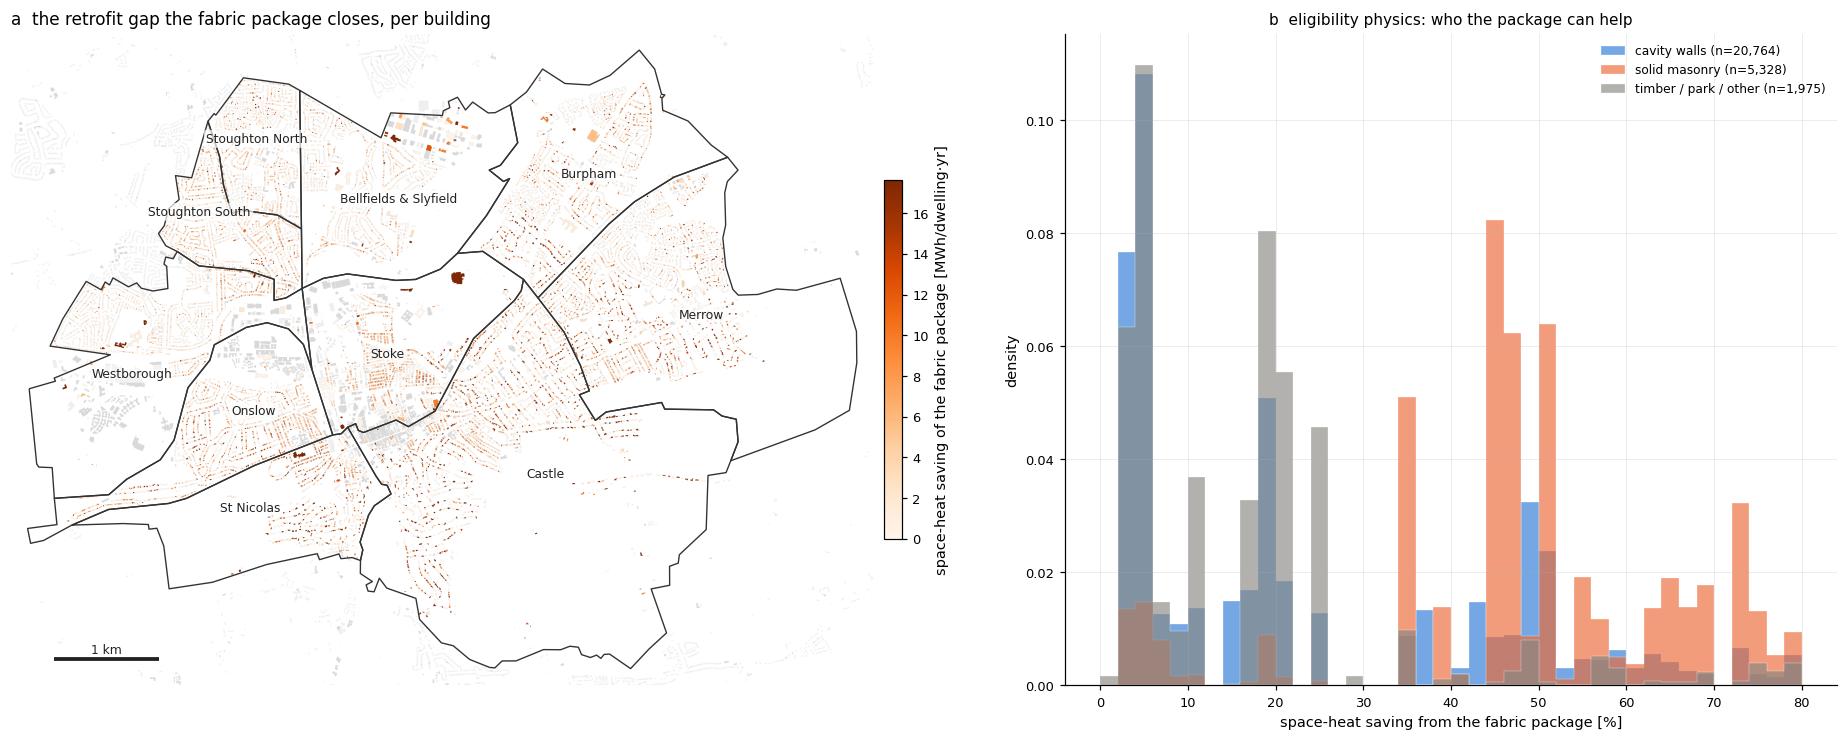

fabric package: 108.0 GWh saved (39 %); median saving by wall group: cavity walls 18 %, solid masonry 48 %, timber / park / other 18 %


In [4]:
gap = (u0["Q_H_kWh"] - u2["Q_H_kWh"]); gap_pct = 100 * gap / u0["Q_H_kWh"].clip(lower=1)
fig, axes = plt.subplots(1, 2, figsize=(17, 6.8), gridspec_kw={"width_ratios": [1.35, 1]})
maps.base_map(axes[0], L); maps.building_map(axes[0], L, maps.per_building(gap / 1e3, urban), cmap="Oranges", label="space-heat saving of the fabric package [MWh/dwelling·yr]", vmin=0, vmax=float((gap / 1e3).quantile(0.97)))
maps.finish(axes[0], L, title="a  the retrofit gap the fabric package closes, per building")
con = urban["wall_construction_resolved"].fillna("Unknown")
grp = np.select([con.eq("Cavity"), con.isin(["Solid brick", "Stone", "System built"])], ["cavity walls", "solid masonry"], default="timber / park / other")
for g, cc in [("cavity walls", "#2a78d6"), ("solid masonry", "#eb6834"), ("timber / park / other", "#898781")]:
    m = (grp == g) & (u0["Q_H_kWh"].to_numpy() > 500)
    axes[1].hist(gap_pct[m], bins=np.arange(0, 81, 2), alpha=0.65, color=cc, label=f"{g} (n={int(m.sum()):,})", density=True, histtype="stepfilled", edgecolor="white", lw=0.3)
axes[1].set_xlabel("space-heat saving from the fabric package [%]"); axes[1].set_ylabel("density"); axes[1].legend(fontsize=8, frameon=False)
axes[1].set_title("b  eligibility physics: who the package can help", fontsize=10)
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PLAN / "12_retrofit_gap"); plt.show()
print(f"fabric package: {gap.sum()/1e6:.1f} GWh saved ({100*gap.sum()/u0['Q_H_kWh'].sum():.0f} %); median saving by wall group: " + ", ".join(f"{g} {np.median(gap_pct[grp == g]):.0f} %" for g in ("cavity walls", "solid masonry", "timber / park / other")))

## 2 · Energy mix and heating technologies by ward (pies in the map)

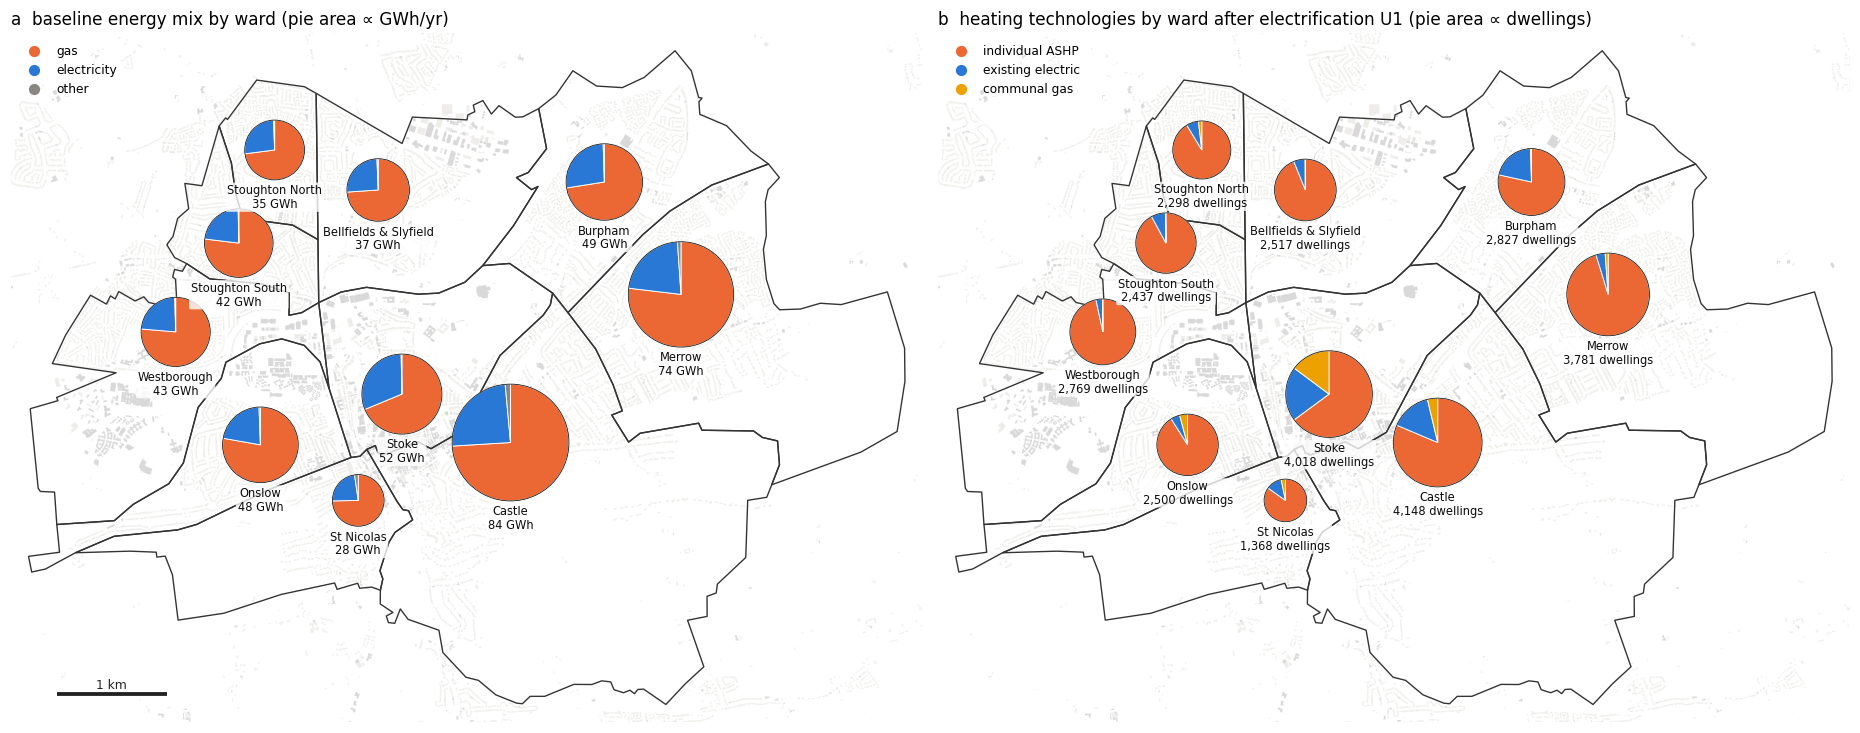

,gas,electricity,other,individual ASHP,existing electric,communal gas
ward,,,,,,
Bellfields & Slyfield,27.4,9.4,0.2,2363,152,2
Burpham,35.6,13.3,0.2,2217,597,13
Castle,62.3,20.6,1.2,3375,619,154
Merrow,57.1,16.4,0.8,3602,135,44
Onslow,37.7,10.5,0.3,2276,120,104
St Nicolas,20.6,6.3,0.6,1161,164,43
Stoke,35.9,16.2,0.2,2607,816,595
Stoughton North,25.3,9.2,0.2,2099,156,43
Stoughton South,32.5,9.6,0.1,2244,186,7


In [5]:
def draw_pie(ax, x, y, fracs, colors, r):
    a0 = 90.0
    for f, cc in zip(fracs, colors):
        if f <= 0: continue
        a1 = a0 - 360 * f; ax.add_patch(Wedge((x, y), r, a1, a0, facecolor=cc, edgecolor="white", lw=0.6, zorder=9)); a0 = a1
    ax.add_patch(Circle((x, y), r, fill=False, edgecolor="#0b0b0b", lw=0.5, zorder=10))
g27 = maps.points_27700(urban[["lon", "lat"]]); wxy = pd.DataFrame({"x": g27.geometry.x.to_numpy(), "y": g27.geometry.y.to_numpy()}, index=urban.index).groupby(urban["ward"]).median()
mix = pd.DataFrame({"gas": u0["delivered_gas_kWh"].groupby(urban["ward"]).sum(), "electricity": u0["delivered_elec_kWh"].groupby(urban["ward"]).sum(), "other": u0["delivered_other_kWh"].groupby(urban["ward"]).sum()}) / 1e6
tech = pd.crosstab(urban["ward"], u1["systems_fam"].map(lambda f: "individual ASHP" if f == "S.HeatPump" else ("communal gas" if f == "S.GasCommunal" else ("existing electric" if f in ("S.ElecResistive", "S.ElecStorage") else "other"))))
tech = tech.reindex(columns=[c for c in ("individual ASHP", "existing electric", "communal gas", "other") if c in tech.columns])
fig, axes = plt.subplots(1, 2, figsize=(17, 7.4))
for ax, table, colors, ttl, scale in [(axes[0], mix, ["#eb6834", "#2a78d6", "#898781"], "a  baseline energy mix by ward (pie area ∝ GWh/yr)", 5.2),
                                      (axes[1], tech, ["#eb6834", "#2a78d6", "#eda100", "#b9b8b1"][:tech.shape[1]], "b  heating technologies by ward after electrification U1 (pie area ∝ dwellings)", 0.075)]:
    maps.base_map(ax, L, res_color="#eeede9")
    for wname, row in table.iterrows():
        tot = row.sum(); r = 90 + scale * tot; draw_pie(ax, wxy.loc[wname, "x"], wxy.loc[wname, "y"], (row / tot).to_numpy(), colors, r)
        NL = chr(10); lab = f"{wname}{NL}{tot:.0f} GWh" if table is mix else f"{wname}{NL}{tot:,.0f} dwellings"
        ax.annotate(lab, (wxy.loc[wname, "x"], wxy.loc[wname, "y"] - r - 40), ha="center", va="top", fontsize=7.5, color="#0b0b0b", zorder=11, bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))
    for f, cc in zip(table.columns, colors): ax.scatter([], [], c=cc, s=40, label=f)
    ax.legend(fontsize=8, frameon=False, loc="upper left"); maps.finish(ax, L, title=ttl, labels=False, bar=(ax is axes[0]))
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PLAN / "12_pies_in_maps"); plt.show()
mix.round(1).join(tech)

## 3 · Prioritisation strategies: the budget percentile at which each building is treated

Every dwelling gets the deep package (U5) with its net upfront cost; the three strategies order the same
dwellings differently and the cumulative spend at each dwelling's turn is its *budget percentile* (0 = treated
first). Carbon-first ranks by kgCO₂e saved per pound; equity-first ranks by an equity score (LSOA deprivation
decile, fuel-poverty share, rented tenure, hard-to-treat flag); coordinated treats substation cells in order of
their electrified peak utilisation (the network constraint of notebook 10) and, inside a cell, by carbon per
pound. The maps show where each order starts.

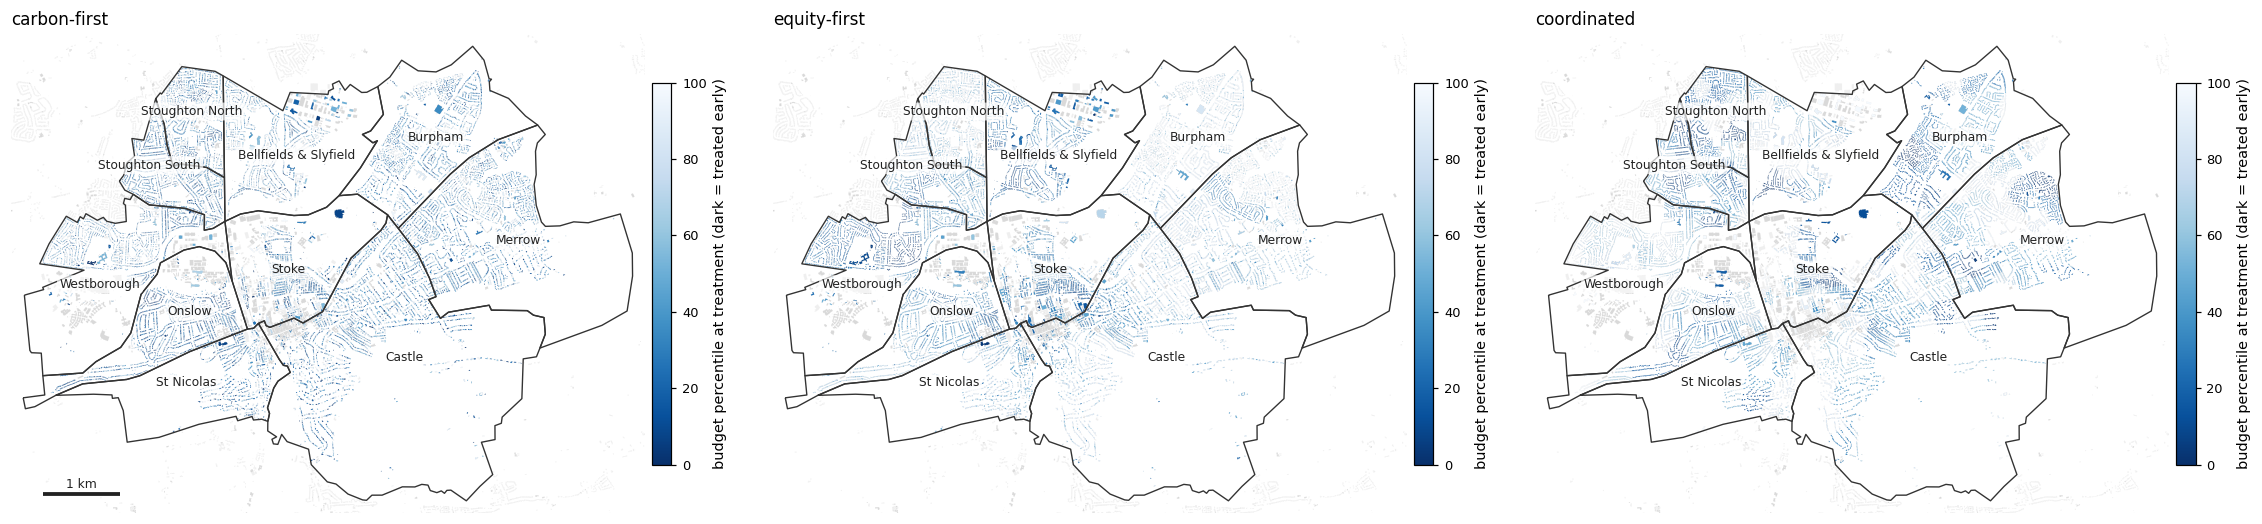

,dwellings in first 25 % of budget,carbon saved kt/yr,rented share %,mean IMD decile,hard-to-treat share %,cells above rating relieved
strategy,,,,,,
carbon-first,8741,26.8,25.7,8.5,20.9,68
equity-first,6867,12.3,82.7,5.8,39.9,49
coordinated,7001,14.9,31.3,8.9,22.2,43


In [6]:
cost = (u5["capex_gross_GBP"] - u5["incentives_GBP"]).clip(lower=0)
carbon_per_gbp = econ["benefit_cost_kg_per_GBP"].fillna(0)
lsoa_soc = urban["LSOA"].map(social["imd_decile"]) if social is not None else pd.Series(5.0, index=urban.index)
fp = urban["LSOA"].map(social["fuel_poor_pct"]) if social is not None else pd.Series(10.0, index=urban.index)
rented = urban["tenure"].astype(str).str.contains("rent").astype(float); htd = econ["HTD"].fillna(False).astype(float)
equity = (11 - lsoa_soc.fillna(5)) / 10 + fp.fillna(fp.median()) / fp.max() + 0.5 * rented + 0.5 * htd
cell_util = pd.Series(cell_of, index=urban.index).map(cells["U1_util_pct"]) if cells is not None else pd.Series(0.0, index=urban.index)
def budget_percentile(order_key):
    o = order_key.sort_values(ascending=False).index
    cum = cost.reindex(o).cumsum() / max(cost.sum(), 1e-9)
    return (100 * cum).reindex(urban.index)
strategies = {"carbon-first": budget_percentile(carbon_per_gbp), "equity-first": budget_percentile(equity),
              "coordinated": budget_percentile(cell_util.fillna(0) * 1e6 + carbon_per_gbp)}
strat = pd.DataFrame(strategies); strat.to_csv(UBEM_OUT / "12_prioritisation_budget_percentile.csv")
fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))
for ax, (name, val) in zip(axes, strategies.items()):
    maps.base_map(ax, L); maps.building_map(ax, L, maps.per_building(val, urban), cmap="Blues_r", vmin=0, vmax=100, label="budget percentile at treatment (dark = treated early)")
    maps.finish(ax, L, title=name, bar=(name == "carbon-first"))
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PLAN / "12_prioritisation_strategies"); plt.show()
# what the first quarter of the budget buys under each strategy
rows = []
for name, val in strategies.items():
    m = val <= 25
    rows.append({"strategy": name, "dwellings in first 25 % of budget": int(m.sum()), "carbon saved kt/yr": (u0.loc[m, "carbon_kg"] - u5.loc[m, "carbon_kg"]).sum() / 1e6,
                 "rented share %": 100 * rented[m].mean(), "mean IMD decile": lsoa_soc[m].mean(), "hard-to-treat share %": 100 * htd[m].mean(),
                 "cells above rating relieved": int(cell_util[m].gt(100).groupby(pd.Series(cell_of, index=urban.index)[m]).any().sum()) if cells is not None else np.nan})
pd.DataFrame(rows).set_index("strategy").round(1)

## 4 · Carbon opportunity × neighbourhood vulnerability

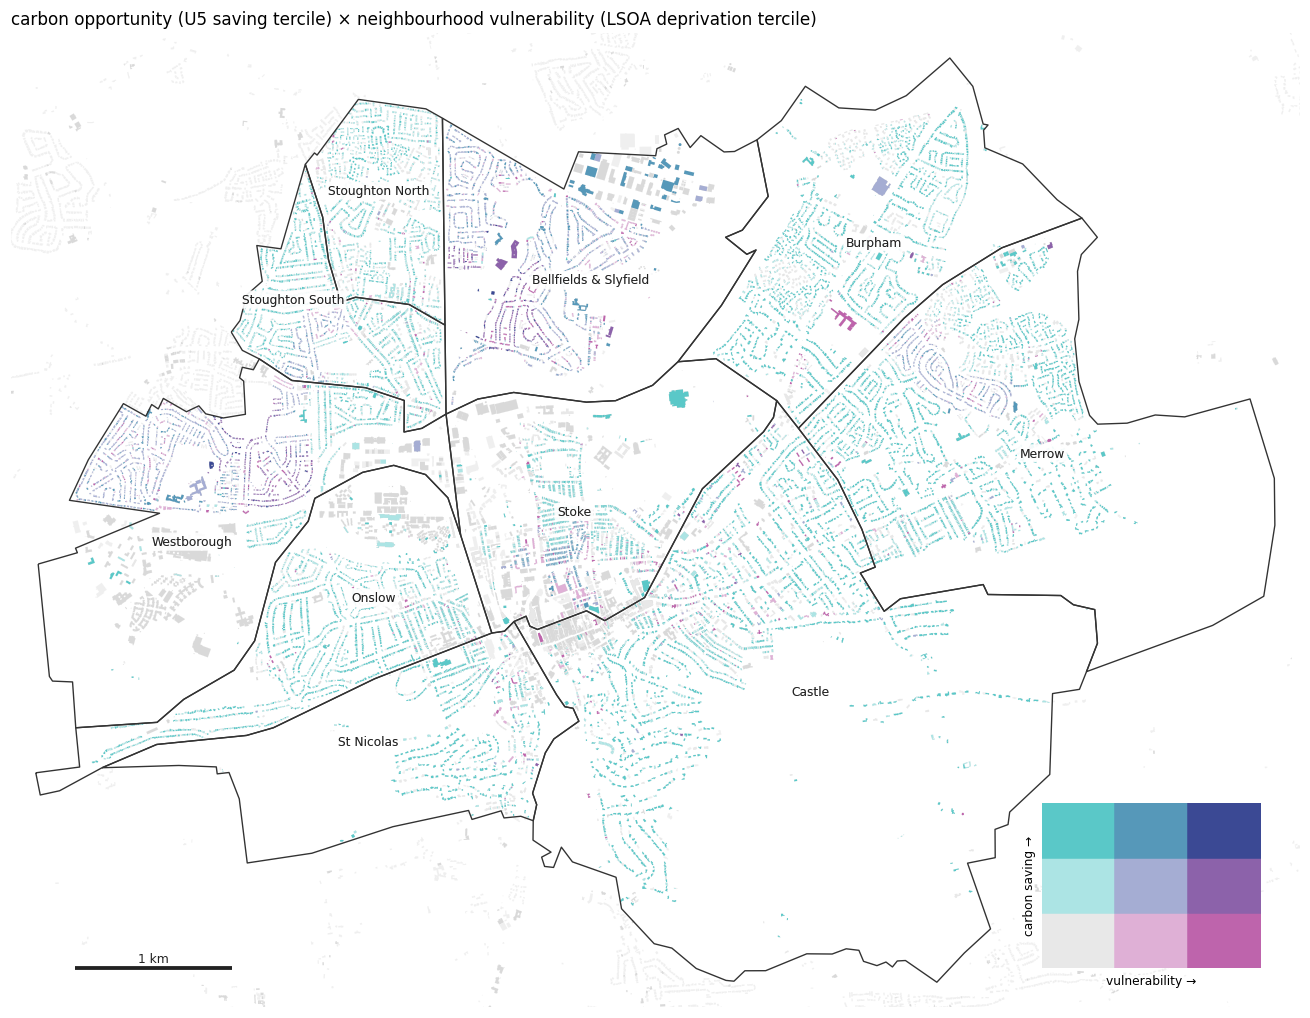

high saving in a high-vulnerability neighbourhood: 169 dwellings (1 %), 0.5 kt/yr of the 57.8 kt/yr deep-package saving


vulnerability,high,low,mid
carbon saving,,,
high,169,8208,1178
low,381,7550,1623
mid,688,6451,2415


In [7]:
BIV = np.array([["#e8e8e8", "#dfb0d6", "#be64ac"], ["#ace4e4", "#a5add3", "#8c62aa"], ["#5ac8c8", "#5698b9", "#3b4994"]])
carbon_save = (u0["carbon_kg"] - u5["carbon_kg"]).clip(lower=0)
ct = pd.qcut(carbon_save.rank(method="first"), 3, labels=False).to_numpy()
dec = lsoa_soc.fillna(5).to_numpy(); vt = np.select([dec >= 7, dec >= 4], [0, 1], default=2)      # IMD decile 1-3 = most deprived = highest vulnerability
cols = pd.Series([BIV[i, j] for i, j in zip(ct, vt)], index=urban.index)
from matplotlib.colors import ListedColormap
code_ = pd.Series(ct * 3 + vt, index=urban.index)
fig, ax = plt.subplots(figsize=(12, 9.5)); maps.base_map(ax, L)
maps.building_map(ax, L, maps.per_building(code_, urban).round(), cmap=ListedColormap(BIV.reshape(-1)), vmin=-0.5, vmax=8.5, legend=False)
maps.ward_labels(ax, L); maps.finish(ax, L, title="carbon opportunity (U5 saving tercile) × neighbourhood vulnerability (LSOA deprivation tercile)")
lx = ax.inset_axes([0.80, 0.04, 0.17, 0.17])
for i in range(3):
    for j in range(3): lx.add_patch(plt.Rectangle((j, i), 1, 1, color=BIV[i, j]))
lx.set_xlim(0, 3); lx.set_ylim(0, 3); lx.set_xticks([]); lx.set_yticks([]); lx.grid(False)
lx.set_xlabel("vulnerability →", fontsize=8); lx.set_ylabel("carbon saving →", fontsize=8)
for s_ in lx.spines.values(): s_.set_visible(False)
plt.tight_layout(); pubstyle.save_fig(fig, FIG_PLAN / "12_carbon_x_vulnerability"); plt.show()
both = (ct == 2) & (vt == 2)
print(f"high saving in a high-vulnerability neighbourhood: {int(both.sum()):,} dwellings ({100*both.mean():.0f} %), {carbon_save[both].sum()/1e6:.1f} kt/yr of the {carbon_save.sum()/1e6:.1f} kt/yr deep-package saving")
pd.crosstab(pd.Series(["low", "mid", "high"])[ct].to_numpy(), pd.Series(["low", "mid", "high"])[vt].to_numpy(), rownames=["carbon saving"], colnames=["vulnerability"])

## What is in `outputs/`

* `outputs/ubem/12_prioritisation_budget_percentile.csv` — the three delivery orders per dwelling;
* figures in `outputs/figures/planning/`: `12_retrofit_gap`, `12_pies_in_maps`, `12_prioritisation_strategies`, `12_carbon_x_vulnerability` (PNG + PDF, 300 dpi).